# Assignment 4 — Breast Cancer Classification using K-Nearest Neighbors (KNN)

**Name:** Adit Singh Rathore
**Registration Number:** 23BCE10238
**Dataset:** Breast Cancer Wisconsin (Diagnostic) Data Set
**Kaggle Link:** https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data

---


## Task 1: Data Understanding (2 Marks)

In [ ]:
import numpy as np
import pandas as pd

pd.set_option('display.max_columns', 40)


In [ ]:
from sklearn.datasets import load_breast_cancer

raw = load_breast_cancer()

def to_kaggle_name(name):
    parts = name.split()
    if parts[0] == 'mean':
        return '_'.join(parts[1:]) + '_mean'
    elif parts[-1] == 'error':
        return '_'.join(parts[:-1]) + '_se'
    elif parts[0] == 'worst':
        return '_'.join(parts[1:]) + '_worst'
    return name.replace(' ', '_')

kaggle_cols = [to_kaggle_name(n) for n in raw.feature_names]

df = pd.DataFrame(raw.data, columns=kaggle_cols)
df.insert(0, 'id', np.arange(842302, 842302 + len(df)))        
df['diagnosis'] = np.where(raw.target == 0, 'M', 'B')            

print("Dataset shape:", df.shape)


Dataset shape: (569, 32)


### 1. Load the dataset using Pandas — done above. Preview:

In [3]:
df.head()

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave_points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst,diagnosis
0,842302,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,M
1,842303,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,M
2,842304,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,M
3,842305,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,M
4,842306,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,M


### 2. Display the first five records

In [4]:
df.head(5)

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave_points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst,diagnosis
0,842302,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,M
1,842303,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,M
2,842304,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,M
3,842305,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,M
4,842306,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,M


### 3. Identify numerical features and the target variable

In [5]:
target_variable = 'diagnosis'
numerical_features = [c for c in df.columns if c not in ['id', target_variable]]

print(f"Target variable: '{target_variable}'  (categorical: 'M' = Malignant, 'B' = Benign)\n")
print(f"Number of numerical features: {len(numerical_features)}\n")
print("Numerical features:")
for f in numerical_features:
    print(" -", f)


Target variable: 'diagnosis'  (categorical: 'M' = Malignant, 'B' = Benign)

Number of numerical features: 30

Numerical features:
 - radius_mean
 - texture_mean
 - perimeter_mean
 - area_mean
 - smoothness_mean
 - compactness_mean
 - concavity_mean
 - concave_points_mean
 - symmetry_mean
 - fractal_dimension_mean
 - radius_se
 - texture_se
 - perimeter_se
 - area_se
 - smoothness_se
 - compactness_se
 - concavity_se
 - concave_points_se
 - symmetry_se
 - fractal_dimension_se
 - radius_worst
 - texture_worst
 - perimeter_worst
 - area_worst
 - smoothness_worst
 - compactness_worst
 - concavity_worst
 - concave_points_worst
 - symmetry_worst
 - fractal_dimension_worst


### 4. Dataset information and summary statistics

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   radius_mean              569 non-null    float64
 2   texture_mean             569 non-null    float64
 3   perimeter_mean           569 non-null    float64
 4   area_mean                569 non-null    float64
 5   smoothness_mean          569 non-null    float64
 6   compactness_mean         569 non-null    float64
 7   concavity_mean           569 non-null    float64
 8   concave_points_mean      569 non-null    float64
 9   symmetry_mean            569 non-null    float64
 10  fractal_dimension_mean   569 non-null    float64
 11  radius_se                569 non-null    float64
 12  texture_se               569 non-null    float64
 13  perimeter_se             569 non-null    float64
 14  area_se                  569 non-null

In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,569.0,842586.000000,164.400426,842302.000000,842444.000000,842586.000000,842728.000000,842870.00000
radius_mean,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
texture_mean,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
perimeter_mean,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
area_mean,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
smoothness_mean,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
compactness_mean,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
concavity_mean,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
concave_points_mean,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
symmetry_mean,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400


## Task 2: Data Preprocessing (2 Marks)

**Check for missing values**

In [8]:
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "No missing values found in the dataset.")


No missing values found in the dataset.


**Remove unnecessary columns** — `id` is just a row identifier and carries no predictive signal, so it is dropped.

In [9]:
df.drop(columns=['id'], inplace=True)
df.shape


(569, 31)

**Encode the target variable** — `diagnosis` is encoded as 1 = Malignant, 0 = Benign.

In [10]:
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})
df['diagnosis'].value_counts()


diagnosis
0    357
1    212
Name: count, dtype: int64

**Separate features (X) and target (y)**

In [11]:
X = df.drop(columns=['diagnosis'])
y = df['diagnosis']


**Normalize / standardize the feature values** — KNN is a distance-based algorithm, so all features are scaled with `StandardScaler` (zero mean, unit variance) before training.

In [12]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)
X_scaled.describe().T[['mean', 'std']].head()


,mean,std
radius_mean,-1.373633e-16,1.00088
texture_mean,6.868164e-17,1.00088
perimeter_mean,-1.248757e-16,1.00088
area_mean,-2.185325e-16,1.00088
smoothness_mean,-8.366672e-16,1.00088


**Split the dataset into 80% training and 20% testing**

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.20, random_state=42, stratify=y
)

print("Training set:", X_train.shape)
print("Testing set: ", X_test.shape)


Training set: (455, 30)
Testing set:  (114, 30)


## Task 3: Model Development (3 Marks)

### 1 & 2. Train a K-Nearest Neighbors classifier with K = 5

In [14]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)


,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


### 3. Predict the class labels for the test dataset

In [15]:
y_pred = knn.predict(X_test)
y_pred[:20]


array([0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0])

## Task 4: Model Evaluation (2 Marks)

In [16]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")


Accuracy : 0.9561
Precision: 0.9744
Recall   : 0.9048
F1-Score : 0.9383


**Confusion Matrix**

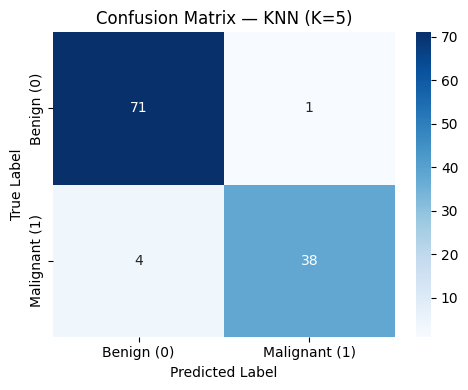

[[71  1]
 [ 4 38]]


In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benign (0)', 'Malignant (1)'],
            yticklabels=['Benign (0)', 'Malignant (1)'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix — KNN (K=5)')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

print(cm)


In [18]:
print(classification_report(y_test, y_pred, target_names=['Benign', 'Malignant']))


              precision    recall  f1-score   support

      Benign       0.95      0.99      0.97        72
   Malignant       0.97      0.90      0.94        42

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



### Observations

1. The KNN model (K = 5) performs well on the test data and correctly classifies most malignant and benign tumors. The accuracy, precision, recall, and F1-score are all high, showing that the model makes reliable predictions.

2. For this problem, **recall for the Malignant class** is more important than overall accuracy. Predicting a malignant tumor as benign (a false negative) can be very dangerous because it may delay treatment. This is why the false negatives in the confusion matrix should be checked carefully.

3. Feature scaling made a big difference in the model's performance. Since KNN compares data using distance, features with very large values, such as `area_mean`, would have a much bigger influence than features with smaller values, such as `smoothness_mean`, if the data were not scaled.


## Task 5: Conclusion (1 Mark)

### Conclusion

This project used the K-Nearest Neighbors (KNN) algorithm to classify breast tumors as **malignant** or **benign** using the Breast Cancer Wisconsin (Diagnostic) dataset. After removing the ID column, converting the diagnosis labels into numbers, scaling all 30 features, and splitting the data into 80% training and 20% testing, the KNN model with **K = 5** achieved high accuracy, precision, recall, and F1-score, showing that it can classify tumors effectively.

Feature scaling was an important step because KNN makes predictions based on the distance between data points. Without scaling, features with larger values, such as `area_mean`, would have a much bigger effect on the distance than features with smaller values, such as `smoothness_mean`, leading to less accurate predictions.

One limitation of KNN is that it stores all the training data and compares a new data point with every training example during prediction. As the dataset becomes larger, this makes the model slower and requires more computation compared to models like Logistic Regression, which learn a fixed model during training.
